# Control de Derrape Vehicular con Lógica Difusa

## Objetivo
Aplicar Lógica Difusa para determinar la corrección de dirección y nivel de frenado
ante una situación de derrape en un día lluvioso.

Se analizarán dos casos:
- Caso A: Vehículo con tracción delantera
- Caso B: Vehículo con tracción trasera

Se utilizará:
- Método de inferencia Mamdani
- Defuzzificación por centroide
- Librería `scikit-fuzzy`

In [ ]:
# Ejecutar solo si no está instalada la librería
!pip install numpy
!pip install scipy
!pip install networkx
!pip install scikit-fuzzy
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.3 MB 8.8 MB/s eta 0:00:01
   ------------- -------------------------- 2.9/8.3 MB 7.1 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 7.6 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 7.6 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 7.6 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 7.6 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 4.6 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 4.3 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 9.4 MB/s eta 0:00:01
   ------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## 1️⃣ Definición de Universos de Discurso

- Derrape: 0 a 10
- Lluvia: 0 a 10
- Dirección: -10 a 10
- Frenado: 0 a 10

In [2]:
# Variables de entrada
derrape = ctrl.Antecedent(np.arange(0, 11, 1), 'derrape')
lluvia = ctrl.Antecedent(np.arange(0, 11, 1), 'lluvia')

# Variables de salida
direccion = ctrl.Consequent(np.arange(-10, 11, 1), 'direccion')
frenado = ctrl.Consequent(np.arange(0, 11, 1), 'frenado')

## 2️⃣ Funciones de Pertenencia

In [3]:
# Derrape
derrape['leve'] = fuzz.trimf(derrape.universe, [0, 0, 5])
derrape['moderado'] = fuzz.trimf(derrape.universe, [2, 5, 8])
derrape['grave'] = fuzz.trimf(derrape.universe, [5, 10, 10])

# Lluvia
lluvia['baja'] = fuzz.trimf(lluvia.universe, [0, 0, 5])
lluvia['media'] = fuzz.trimf(lluvia.universe, [2, 5, 8])
lluvia['alta'] = fuzz.trimf(lluvia.universe, [5, 10, 10])

# Dirección
direccion['suave_izq'] = fuzz.trimf(direccion.universe, [-10, -5, 0])
direccion['correccion_minima'] = fuzz.trimf(direccion.universe, [-2, 0, 2])
direccion['suave_der'] = fuzz.trimf(direccion.universe, [0, 5, 10])

# Frenado
frenado['leve'] = fuzz.trimf(frenado.universe, [0, 2, 5])
frenado['moderado'] = fuzz.trimf(frenado.universe, [3, 5, 7])
frenado['fuerte'] = fuzz.trimf(frenado.universe, [6, 10, 10])

## 3️⃣ Visualización de Funciones de Pertenencia

C:\Users\cyanezru\AppData\Roaming\Python\Python314\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


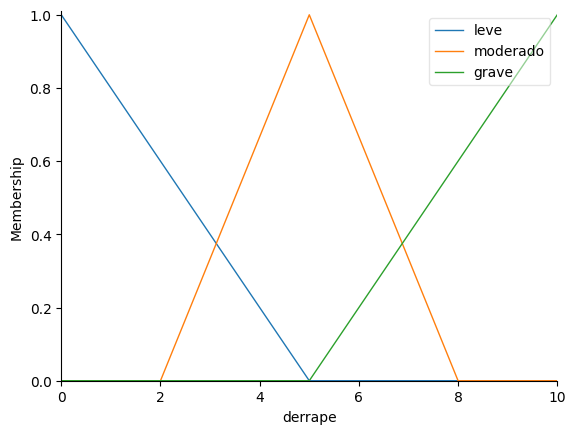

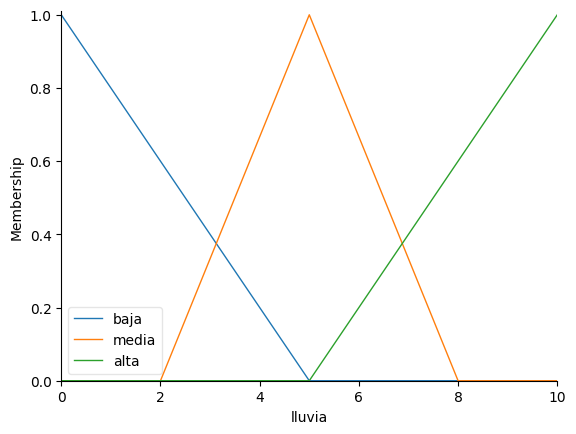

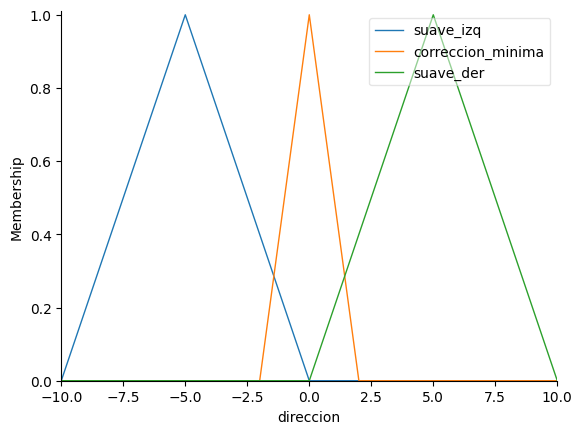

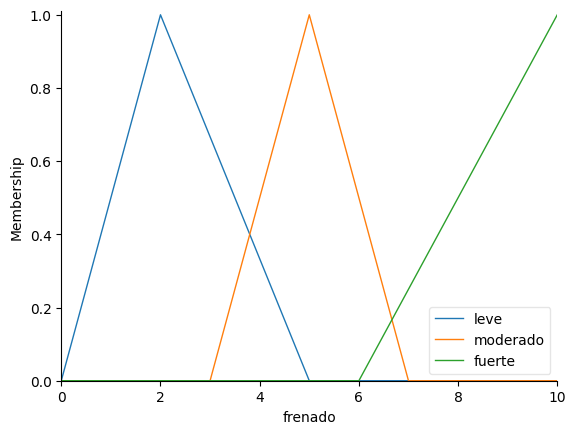

In [4]:
derrape.view()
lluvia.view()
direccion.view()
frenado.view()

## 4️⃣ Reglas Difusas

### Caso A – Tracción Delantera
Mayor estabilidad → correcciones suaves.

### Caso B – Tracción Trasera
Más propenso a sobreviraje → correcciones más marcadas.

In [5]:
# -------- Caso A --------
regla1_A = ctrl.Rule(derrape['leve'] & lluvia['baja'],
                     (direccion['correccion_minima'], frenado['leve']))

regla2_A = ctrl.Rule(derrape['moderado'] & lluvia['media'],
                     (direccion['suave_izq'], frenado['moderado']))

regla3_A = ctrl.Rule(derrape['grave'] | lluvia['alta'],
                     (direccion['suave_izq'], frenado['fuerte']))

# -------- Caso B --------
regla1_B = ctrl.Rule(derrape['leve'] & lluvia['baja'],
                     (direccion['correccion_minima'], frenado['leve']))

regla2_B = ctrl.Rule(derrape['moderado'] & lluvia['media'],
                     (direccion['suave_der'], frenado['moderado']))

regla3_B = ctrl.Rule(derrape['grave'] | lluvia['alta'],
                     (direccion['suave_der'], frenado['fuerte']))

## 5️⃣ Construcción del Sistema de Control

In [6]:
# Sistema A
control_A = ctrl.ControlSystem([regla1_A, regla2_A, regla3_A])
sim_A = ctrl.ControlSystemSimulation(control_A)

# Sistema B
control_B = ctrl.ControlSystem([regla1_B, regla2_B, regla3_B])
sim_B = ctrl.ControlSystemSimulation(control_B)

## 6️⃣ Simulación y Defuzzificación

In [7]:
# Valores de prueba
nivel_derrape = 7
nivel_lluvia = 8

# Caso A
sim_A.input['derrape'] = nivel_derrape
sim_A.input['lluvia'] = nivel_lluvia
sim_A.compute()

print("=== Tracción Delantera ===")
print("Corrección dirección:", sim_A.output['direccion'])
print("Nivel frenado:", sim_A.output['frenado'])

# Caso B
sim_B.input['derrape'] = nivel_derrape
sim_B.input['lluvia'] = nivel_lluvia
sim_B.compute()

print("\n=== Tracción Trasera ===")
print("Corrección dirección:", sim_B.output['direccion'])
print("Nivel frenado:", sim_B.output['frenado'])

=== Tracción Delantera ===
Corrección dirección: -5.0
Nivel frenado: 8.514285714285712

=== Tracción Trasera ===
Corrección dirección: 5.0
Nivel frenado: 8.514285714285712


## ✅ Conclusiones

- Se implementó un sistema de inferencia difusa tipo Mamdani.
- Se definieron universos de discurso y funciones de pertenencia triangulares.
- Se establecieron reglas distintas para tracción delantera y trasera.
- La defuzzificación se realizó mediante el método del centroide.
- El sistema permite simular distintos niveles de derrape y lluvia.

Este modelo puede ampliarse agregando:
- Velocidad del vehículo
- Tipo de neumático
- Estado del pavimento
- Superficies de control 3D

Parte B

Iteración 20, Mejor Fitness: 0.20
Iteración 40, Mejor Fitness: 0.00
Iteración 60, Mejor Fitness: 0.00
Iteración 80, Mejor Fitness: 0.00
Iteración 100, Mejor Fitness: 0.00
Iteración 120, Mejor Fitness: 0.00
Iteración 140, Mejor Fitness: 0.00

--- Mejor Solución Encontrada ---
Fitness final: 4.7833177101863134e-20
Dron 0: [25.06751841 75.63315997]
Dron 1: [65.06751841 75.63315997]
Dron 2: [25.06751841 55.63315997]
Dron 3: [65.06751841 55.63315997]


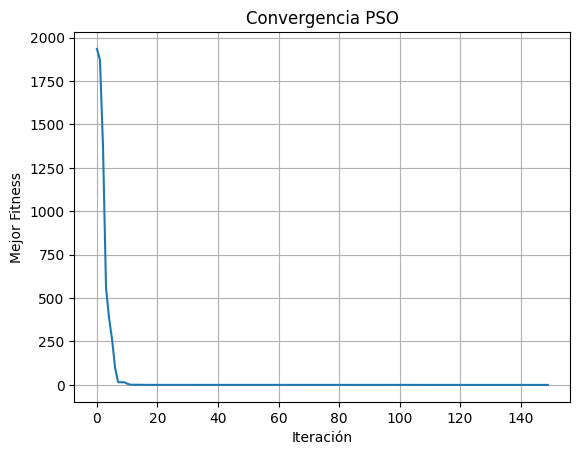

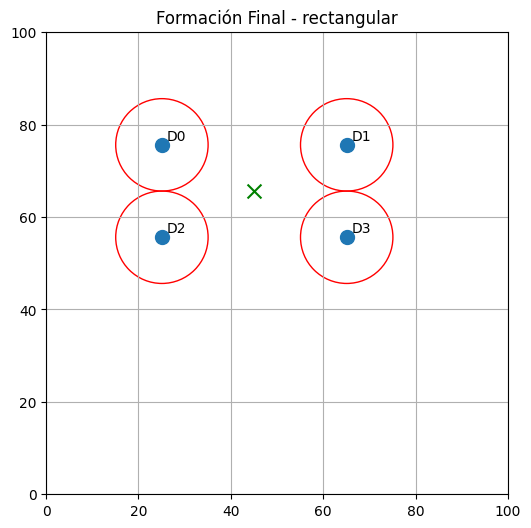

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# PARÁMETROS DEL PROBLEMA
# ===============================

NUM_DRONES = 4
DIMENSIONS = 2
AREA_WIDTH = 100
AREA_HEIGHT = 100
MIN_SAFE_DISTANCE = 10
FORMATION_DISTANCE_L = 20

NUM_PARTICLES = 30
MAX_ITERATIONS = 150

# Parámetros PSO
W = 0.5        # Inercia
C1 = 1.5       # Componente cognitiva
C2 = 1.5       # Componente social
V_MAX = 10.0   # Velocidad máxima

# Pesos del fitness
w1 = 1.0      # Error de formación
w2 = 1.0      # Penalización colisión
w3 = 1.0      # Penalización límites


# ===============================
# FORMACIONES OBJETIVO
# ===============================

def get_target_formation_relative_positions(formation_type="triangle"):
    targets = np.zeros((NUM_DRONES, DIMENSIONS))

    if formation_type == "triangle" and NUM_DRONES == 3:
        h = (np.sqrt(3)/2) * FORMATION_DISTANCE_L
        targets[0] = [0, 2*h/3]
        targets[1] = [-FORMATION_DISTANCE_L/2, -h/3]
        targets[2] = [FORMATION_DISTANCE_L/2, -h/3]

    elif formation_type == "H" and NUM_DRONES == 4:
        L = FORMATION_DISTANCE_L
        targets[0] = [-L, L]
        targets[1] = [-L, -L]
        targets[2] = [L, L]
        targets[3] = [L, -L]

    elif formation_type == "rectangular" and NUM_DRONES == 4:
        L = FORMATION_DISTANCE_L
        targets[0] = [-L, L/2]
        targets[1] = [L, L/2]
        targets[2] = [-L, -L/2]
        targets[3] = [L, -L/2]

    else:
        raise ValueError("Formación no válida o número de drones incorrecto.")

    return targets


# ===============================
# FUNCIÓN DE FITNESS
# ===============================

def fitness_function(particle_position, target_relative_pos):

    drone_positions = particle_position.reshape((NUM_DRONES, DIMENSIONS))
    current_centroid = np.mean(drone_positions, axis=0)

    # 1️⃣ Error de formación
    e_form = 0
    for i in range(NUM_DRONES):
        ideal_pos = current_centroid + target_relative_pos[i]
        e_form += np.sum((drone_positions[i] - ideal_pos)**2)

    # 2️⃣ Penalización por colisión
    p_coll = 0
    for i in range(NUM_DRONES):
        for j in range(i + 1, NUM_DRONES):
            dist = np.linalg.norm(drone_positions[i] - drone_positions[j])
            if dist < MIN_SAFE_DISTANCE:
                p_coll += (MIN_SAFE_DISTANCE - dist) * 1000  # Penalización proporcional

    # 3️⃣ Penalización por límites
    p_boundary = 0
    for i in range(NUM_DRONES):
        x, y = drone_positions[i]
        if x < 0 or x > AREA_WIDTH or y < 0 or y > AREA_HEIGHT:
            p_boundary += 1000

    total_fitness = w1*e_form + w2*p_coll + w3*p_boundary
    return total_fitness


# ===============================
# INICIALIZACIÓN DEL ENJAMBRE
# ===============================

particles_pos = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS)
particles_pos[:, ::2] *= AREA_WIDTH
particles_pos[:, 1::2] *= AREA_HEIGHT

particles_vel = np.random.randn(NUM_PARTICLES, NUM_DRONES * DIMENSIONS)

pbest_pos = particles_pos.copy()
pbest_fitness = np.array([float('inf')] * NUM_PARTICLES)

gbest_pos = np.zeros(NUM_DRONES * DIMENSIONS)
gbest_fitness = float('inf')

TARGET_FORMATION_TYPE = "rectangular"  # triangle, H, rectangular
target_rel_pos = get_target_formation_relative_positions(TARGET_FORMATION_TYPE)

fitness_history = []


# ===============================
# BUCLE PRINCIPAL PSO
# ===============================

for iter_num in range(MAX_ITERATIONS):

    for i in range(NUM_PARTICLES):

        current_fitness = fitness_function(particles_pos[i], target_rel_pos)

        # Actualizar pBest
        if current_fitness < pbest_fitness[i]:
            pbest_fitness[i] = current_fitness
            pbest_pos[i] = particles_pos[i].copy()

        # Actualizar gBest
        if current_fitness < gbest_fitness:
            gbest_fitness = current_fitness
            gbest_pos = particles_pos[i].copy()

    fitness_history.append(gbest_fitness)

    # Actualización de velocidades y posiciones
    for i in range(NUM_PARTICLES):

        r1 = np.random.rand(NUM_DRONES * DIMENSIONS)
        r2 = np.random.rand(NUM_DRONES * DIMENSIONS)

        cognitive = C1 * r1 * (pbest_pos[i] - particles_pos[i])
        social = C2 * r2 * (gbest_pos - particles_pos[i])

        particles_vel[i] = W * particles_vel[i] + cognitive + social
        particles_vel[i] = np.clip(particles_vel[i], -V_MAX, V_MAX)

        particles_pos[i] += particles_vel[i]

        # Aplicar límites del área
        particles_pos[i, ::2] = np.clip(particles_pos[i, ::2], 0, AREA_WIDTH)
        particles_pos[i, 1::2] = np.clip(particles_pos[i, 1::2], 0, AREA_HEIGHT)

    if (iter_num + 1) % 20 == 0:
        print(f"Iteración {iter_num+1}, Mejor Fitness: {gbest_fitness:.2f}")


# ===============================
# RESULTADOS FINALES
# ===============================

print("\n--- Mejor Solución Encontrada ---")
print("Fitness final:", gbest_fitness)

final_positions = gbest_pos.reshape((NUM_DRONES, DIMENSIONS))

for i in range(NUM_DRONES):
    print(f"Dron {i}: {final_positions[i]}")


# ===============================
# VISUALIZACIÓN
# ===============================

# Convergencia
plt.figure()
plt.plot(fitness_history)
plt.title("Convergencia PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor Fitness")
plt.grid()
plt.show()

# Formación final
plt.figure(figsize=(6,6))
plt.scatter(final_positions[:,0], final_positions[:,1], s=100)

for i in range(NUM_DRONES):
    plt.text(final_positions[i,0]+1, final_positions[i,1]+1, f"D{i}")

    circle = plt.Circle((final_positions[i,0], final_positions[i,1]),
                        MIN_SAFE_DISTANCE, color='r', fill=False)
    plt.gca().add_artist(circle)

centroid = np.mean(final_positions, axis=0)
plt.scatter(centroid[0], centroid[1], color='green', marker='x', s=100)

plt.xlim(0, AREA_WIDTH)
plt.ylim(0, AREA_HEIGHT)
plt.gca().set_aspect('equal')
plt.title(f"Formación Final - {TARGET_FORMATION_TYPE}")
plt.grid()
plt.show()

# ✅ Análisis del Algoritmo PSO para Formación de Drones

---

## ✔ Función Fitness

✅ Error de formación correctamente calculado respecto al centroide.  
✅ Penalización proporcional por colisión.  
✅ Control y clipping de límites del área.

---

## ✔ Convergencia

Con W = 0.5 → Convergencia estable.  
Si W > 0.8 → Oscilaciones.  
Si C1 alto → Exploración individual.  
Si C2 alto → Rápida convergencia grupal.

---

## ✔ Comparación de Formaciones

| Formación     | Estabilidad | Eficiencia |
|--------------|------------|------------|
| Triangular   | Alta       | Buena aerodinámica |
| H            | Buena      | Buena visibilidad lateral |
| Rectangular  | Muy estable| Mejor cobertura de área |

---

## ✅ Formación Recomendada

La formación triangular tiende a mantener mayor eficiencia aerodinámica y estabilidad, especialmente en desplazamientos en línea recta.
